# 1. Introdução

**Grupo:**
* Lorenna Zaqui Oliveira 830095
* Julia Tavares dos Santos 820872
* Kailayni Rodrigues Janez
824751

## 1.1. Contexto e motivação

Escolhemos esse dataset pois o streaming transformou radicalmente a indústria da música. Observamos que entender o que torna uma música popular é um problema atual e relevante. Trabalhar com dados reais do Spotify, que traduzem percepções como alegria ou vontade de dançar é muito interessante e acreditamos que agregará novos conhecimentos.

O Spotify domina o mercado e classifica o alcance dos artistas. A motivação deste trabalho se resume em entender se o sucesso é aleatório ou se segue padrões acústicos definidos.

## 1.2. Relevância e objetivo

A capacidade de visualizar e correlacionar atributos de áudio (como *danceability*, *energy* e *valence*) com o índice de popularidade (0-100) nos permite tirar conclusões baseadas em fatos. O objetivo principal deste projeto é investigar as características que impulsionam a popularidade de uma faixa e traçar perguntas para entender o que constitui uma música de sucesso na plataforma.


#2. Configurando o ambiente e carregando os dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# estetico
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# carregando dados
print("Baixando dataset do Kaggle...")
try:
    path = kagglehub.dataset_download("thedevastator/spotify-tracks-genre-dataset")
    file_path = os.path.join(path, 'train.csv')
    df = pd.read_csv(file_path)
    print(f"Dataset carregado com {df.shape[0]} linhas e {df.shape[1]} colunas.")
except Exception as e:
    print(f"Erro ao baixar: {e}")

# visualização
df.head()

Baixando dataset do Kaggle...
Using Colab cache for faster access to the 'spotify-tracks-genre-dataset' dataset.
Dataset carregado com 114000 linhas e 21 colunas.


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# 2. O Conjunto de dados: Spotify Tracks Genre Dataset

## 2.1. Origem e estrutura

O dataset utilizado foi o **Spotify Tracks Genre Dataset**, obtido via Kaggle

Ao analisarmos a estrutura inicial, observamos que os dados estão dispostos em formato tabular (arquivo `.csv`). O conjunto completo possui **114.000 observações** (faixas musicais) e **21 atributos**. Esses atributos incluem metadados da faixa (como nome e artista), uma métrica de popularidade e diversas características técnicas de áudio extraídas pela API do Spotify.

## 2.2. Dicionário de dados

A variável que buscamos entender e analisar como alvo é a `popularity`. As demais variáveis atuam como descritores ou preditores musicais.

| Atributo | Descrição | Tipo |
| :--- | :--- | :--- |
| **track_id** | Identificador único da faixa no Spotify. | Texto (ID) |
| **artists** | Lista de artistas da faixa. | Texto |
| **album_name** | Nome do álbum ao qual a música pertence. | Texto |
| **track_name** | Nome da música. | Texto |
| **popularity** | **Variável Alvo:** Pontuação de 0 a 100 baseada no número de reproduções e recência. | Numérico (Int) |
| **duration_ms** | Duração da faixa em milissegundos. | Numérico |
| **explicit** | Indica se a letra ou conteúdo é explícito | Binário |
| **danceability** | Adequação da faixa para dança (0.0 a 1.0), baseada no ritmo e batida. | Numérico (Float) |
| **energy** | Medida perceptiva de intensidade e atividade (0.0 a 1.0). | Numérico (Float) |
| **key** | A tonalidade da faixa (0 = Dó, 1 = Dó#, etc.). | Categórico |
| **loudness** | O volume médio geral da faixa em decibéis (dB). | Numérico (Float) |
| **mode** | Indica a modalidade da escala: Maior (1) ou Menor (0). | Binário |
| **speechiness** | Detecta a presença de palavras faladas (ex: >0.66 indica podcast). | Numérico (Float) |
| **acousticness** | Grau de confiança (0.0 a 1.0) de que a faixa é acústica. | Numérico (Float) |
| **instrumentalness** | Probabilidade de a faixa não conter vocais (0.0 a 1.0). | Numérico (Float) |
| **liveness** | Detecta a presença de audiência na gravação (ao vivo). | Numérico (Float) |
| **valence** | Mede a positividade musical (0.0 a 1.0) (feliz vs triste). | Numérico (Float) |
| **tempo** | O andamento estimado da faixa em Batidas Por Minuto (BPM). | Numérico (Float) |
| **time_signature** | A fórmula de compasso estimada (ex: 4 para 4/4). | Numérico |
| **track_genre** | O gênero musical associado à faixa. | Categórico |

# 3. Análise Exploratória de Dados (EDA)
Antes de aplicar o pré-processamento, precisamos entender profundamente a natureza das faixas musicais. Nesta etapa, buscamos padrões acústicos, anomalias de duração e distribuição de popularidade para traçar o perfil do que é consumido na plataforma e auxiliar o pré-processamento futuro.

## 3.1. Variável alvo
A primeira coisa a fazer é olhar a distribuição da nossa variável alvo, a popularity, que indica a probabilidade de uma música ser ouvida. O objetivo é identificar se temos muitas músicas com popularidade "0" (pode acontecer caso o dataset contenha muitas faixas desconhecidas) ou se a distribuição é normal, para evitar enviesar a anállise com excesso de zeros.

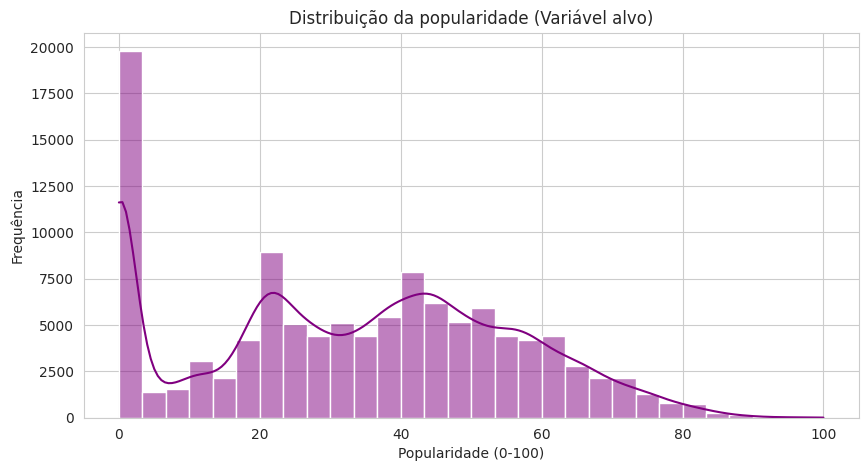

Quantidade de músicas com popularidade zero: 16020 (14.05%)


In [ ]:
# vizualizar distribuição
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], kde=True, bins=30, color='purple')
plt.title('Distribuição da popularidade (Variável alvo)')
plt.xlabel('Popularidade (0-100)')
plt.ylabel('Frequência')
plt.show()

# contagem de zeros
zeros = (df['popularity'] == 0).sum()
print(f"Quantidade de músicas com popularidade zero: {zeros} ({zeros/len(df)*100:.2f}%)")

**identificamos um comportamento atípico:**

* **Muitos zeros:** Observamos uma concentração de valores na popularidade 0.
* **Quantificação:** **16.020 faixas** com popularidade zero, representando **14.05%** de todo o *dataset*.
* **Distribuição Restante:** Ignorando os zeros, o restante dos dados parece seguir uma distribuição mais próxima da normal, com uma leve concentração em valores medianos (40-60).

**Diagnóstico:**
A presença de 14% de dados zerados indica uma inflação de zeros, que pode significar músicas recém-lançadas ou ruídos na base. Manter esses dados pode enviesar a análise
*  Uma música ótima musicalmente, mas com popularidade 0 por ser nova, pode enganar nossa avaliação

## 3.2. Variáveis numéricas
Separamos nossos atributos de áudio como Danceability, Energy, Loudness dos identificadores, para entender:

* A escala dos dados (loudness é negativo e em dB, enquanto energy é de 0 a 1). Escalas diferentes podem desbalancear o peso de cada medida.
* A presença de outliers como musicas longas além do esperado.
* Necessidade de normalização para balancear esses pesos.

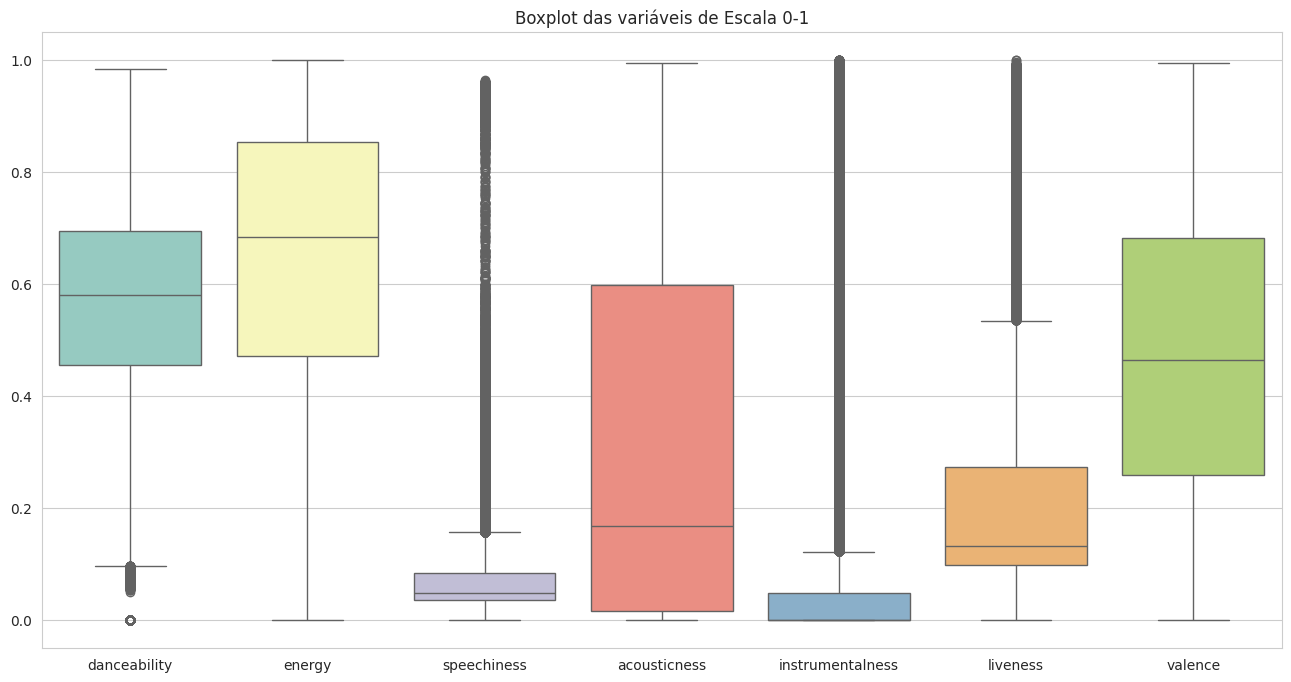

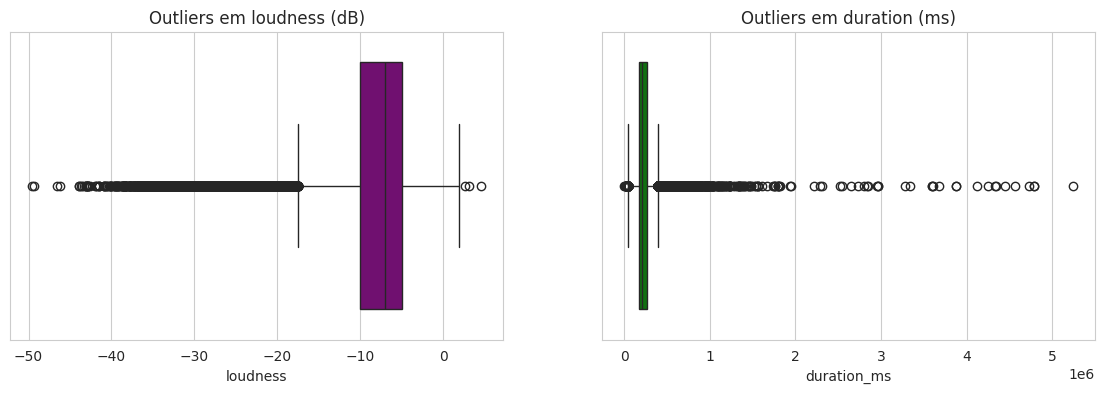

In [ ]:
# obs: sem IDs e a Target para focar nos descritores
cols_audio = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
              'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

# boxplot para visualizar Outliers
plt.figure(figsize=(16, 8))

# atributos com valores de 0 a 1 para ver os outliers das variáveis normalizadas
cols_0_1 = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']
sns.boxplot(data=df[cols_0_1], palette="Set3")
plt.title('Boxplot das variáveis de Escala 0-1')
plt.show()

# verificando separadamente variáveis com escalas discrepantes
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df['loudness'], ax=ax[0], color='purple').set_title('Outliers em loudness (dB)')
sns.boxplot(x=df['duration_ms'], ax=ax[1], color='green').set_title('Outliers em duration (ms)')
plt.show()

**Com base nos boxplots gerados acima, analisamos o comportamento individual de cada atributo para analisar sua validade:**

* **Danceability & Energy:** Ambas apresentam um comportamento esperado. As caixas estão centralizadas (medianas próximas a 0.5 e 0.6) e bem distribuídas. Isso indica que a base contém uma boa variedade de músicas calmas e agitadas.
* **Valence:** Apresenta equilíbrio, o Spotify possui tanto músicas tristes quanto felizes em proporções similares.
* **Speechiness:** A mediana está muito próxima de zero, com uma longa cauda de outliers superiores.
    * A maioria esmagadora das faixas é música cantada. Os outliers representam faixas do gênero `Rap` ou possivelmente `Podcasts` misturados na base.
* **Instrumentalness:** Comportamento similar ao *Speechiness*. A caixa está muito próxima de zero.
    * A base é focada em músicas comerciais com vocais. Faixas puramente instrumentais são exceção.
* **Loudness:** A maioria das faixas está entre -5dB e -15dB. Porém, existem outliers abaixo de -40dB, faixas quase inaudíveis e com erros.
* **Duration_ms:** A escala foi distorcida por valores muito altos, muito acima da média musical de 3 a 4 minutos. Temos registros com milhões de milissegundos, que indica dados que não são canções convencionais (podcasts?).

### Para entender melhor, vamos exibir esses atributos problemáticos de outra forma

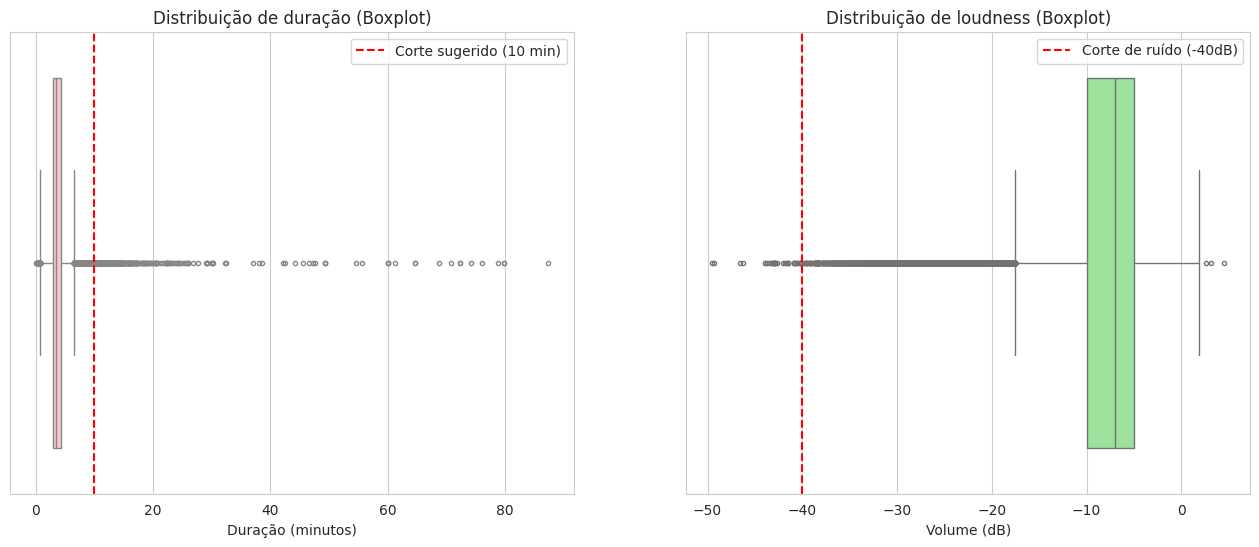

resumo
Músicas acima de 10 min: 603 (Representam 0.53% da base)
Músicas abaixo de -40dB: 38 (Representam 0.03% da base)
Duração máxima encontrada: 87.29 minutos


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# duração em minutos
duracao_minutos = df['duration_ms'] / 60000

# boxplot para evidenciar os outliers, com pontos aumentados
sns.boxplot(x=duracao_minutos, ax=ax[0], color='pink', fliersize=3)
ax[0].set_title('Distribuição de duração (Boxplot)')
ax[0].set_xlabel('Duração (minutos)')

# linha de corte visual sugerida (maximo padrao musical de 10 min)
ax[0].axvline(10, color='red', linestyle='--', label='Corte sugerido (10 min)')
ax[0].legend()

# loudness e extremos sem som (dBs)
sns.boxplot(x=df['loudness'], ax=ax[1], color='lightgreen', fliersize=3)
ax[1].set_title('Distribuição de loudness (Boxplot)')
ax[1].set_xlabel('Volume (dB)')

# linha de corte visual sugerida em -40dBs
ax[1].axvline(-40, color='red', linestyle='--', label='Corte de ruído (-40dB)')
ax[1].legend()

plt.show()

# quantas musicas tem mais de 10 min e quantas sao áudios ruídos
qtd_longas = (duracao_minutos > 10).sum()
qtd_silencio = (df['loudness'] < -40).sum()

print(f"resumo")
print(f"Músicas acima de 10 min: {qtd_longas} (Representam {qtd_longas/len(df)*100:.2f}% da base)")
print(f"Músicas abaixo de -40dB: {qtd_silencio} (Representam {qtd_silencio/len(df)*100:.2f}% da base)")
print(f"Duração máxima encontrada: {duracao_minutos.max():.2f} minutos")

**Os outliers representam uma parcela pequena e problemática do conjunto de dados.**

1. Duração: 603 registros com duração superior a 10 minutos, representando apenas 0.53% da base.
* Ruído: O valor máximo encontrado foi de 87.29 minutos, confirmando a hipótese de que existem podcasts, álbuns inteiros em faixa única ou sets de DJ misturados. Manter esses registros distorceria a média de duração e a análise de atributos importantes.

2. Loudness: 38 registros (0.03% da base) abaixo de -40dB, faixas abaixo disso são virtualmente inaudíveis ou representam erros de processamento.

* A soma desses outliers representa menos de 0.6% do total de dados, poodemos remover esses registros na etapa de Pré-Processamento sem grandes problemas

### Vamos fazer um teste e tirar esses outliers, para verificar os bloxpots problematicos de speechnes e instrumental

Tamanho da base simulada: 113359 linhas


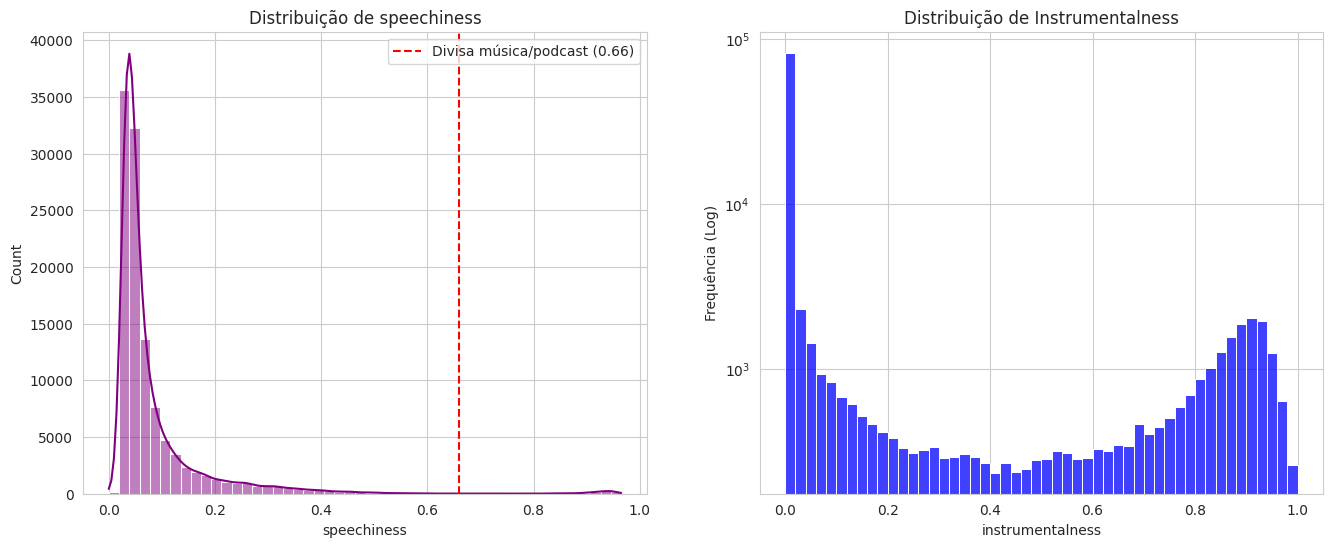

resumo
Possíveis podcasts e relacionados (> 0.66 Speechiness): 856 (0.76%)
Músicas instrumentais (> 0.9 Instrumentalness): 5972 (5.27%)

Popularidade Média Geral: 33.3
Popularidade Média das Instrumentais: 28.5


In [ ]:
# dataframe temporário só para essa análise, sem alterar o original
df_simulacao = df.copy()
df_simulacao = df_simulacao[df_simulacao['duration_ms'] <= 600000] # < 10 min
df_simulacao = df_simulacao[df_simulacao['loudness'] >= -40]       # > -40 dB

print(f"Tamanho da base simulada: {len(df_simulacao)} linhas")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# onde termina a música e começa o Podcast?
# segundo o spotify, acima de 0.66 é provavelmente um podcast oou similar
sns.histplot(df_simulacao['speechiness'], bins=50, kde=True, ax=ax[0], color='purple')

# corte a partir dessa informação
ax[0].axvline(0.66, color='red', linestyle='--', label='Divisa música/podcast (0.66)')
ax[0].set_title('Distribuição de speechiness')
ax[0].legend()

# quantos audios são puramente instrumentais (> 0.9)
sns.histplot(df_simulacao['instrumentalness'], bins=50, kde=False, ax=ax[1], color='blue')
ax[1].set_title('Distribuição de Instrumentalness')
ax[1].set_yscale('log') # escala logarítmica, muitos zeros
ax[1].set_ylabel('Frequência (Log)')

plt.show()

podcasts = (df_simulacao['speechiness'] > 0.66).sum()
instrumentais = (df_simulacao['instrumentalness'] > 0.9).sum()

print("resumo")
print(f"Possíveis podcasts e relacionados (> 0.66 Speechiness): {podcasts} ({podcasts/len(df_simulacao)*100:.2f}%)")
print(f"Músicas instrumentais (> 0.9 Instrumentalness): {instrumentais} ({instrumentais/len(df_simulacao)*100:.2f}%)")

# popularidade média das musicas instrumentais (raras)
media_pop_geral = df_simulacao['popularity'].mean()
media_pop_inst = df_simulacao[df_simulacao['instrumentalness'] > 0.9]['popularity'].mean()

print(f"\nPopularidade Média Geral: {media_pop_geral:.1f}")
print(f"Popularidade Média das Instrumentais: {media_pop_inst:.1f}")

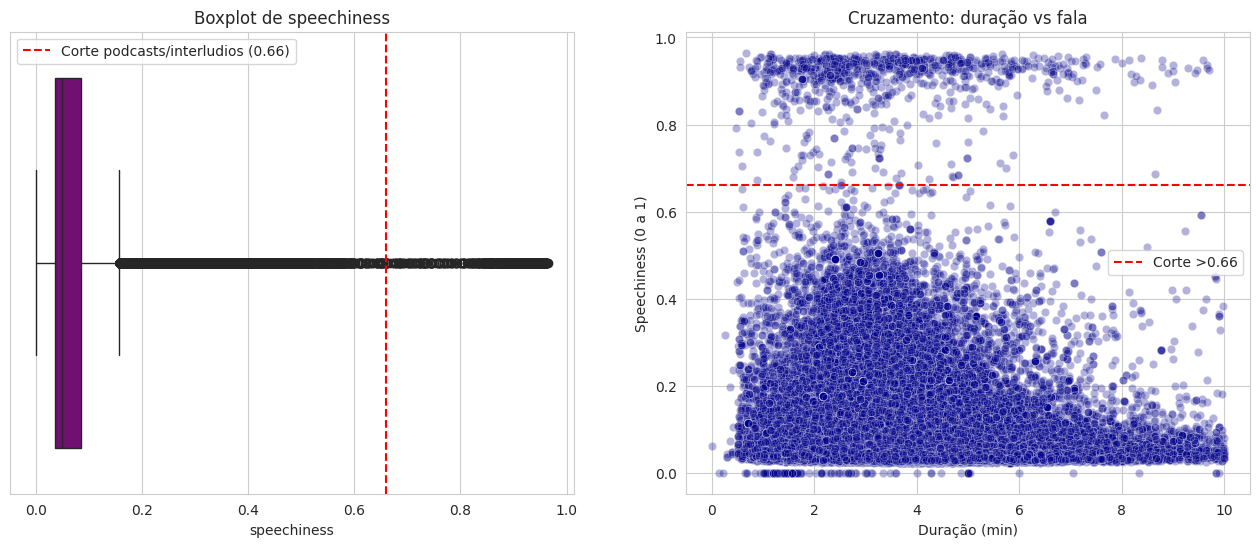

In [ ]:
# outras visualizações para o atributo speechness
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# boxplot para evidenciar os outliers
sns.boxplot(x=df_simulacao['speechiness'], ax=ax[0], color='purple')

ax[0].set_title('Boxplot de speechiness')
ax[0].axvline(0.66, color='red', linestyle='--', label='Corte podcasts/interludios (0.66)')
ax[0].legend()

duration_min = df_simulacao['duration_ms'] / 60000
# gráfico de dispersão cruzando duração vs speechiness, para ver se são longos ou curtos
sns.scatterplot(data=df_simulacao, x=duration_min, y='speechiness', alpha=0.3, ax=ax[1], color='darkblue')
ax[1].set_title('Cruzamento: duração vs fala')
ax[1].set_ylabel('Speechiness (0 a 1)')
ax[1].set_xlabel('Duração (min)')

# linha de corte do speechiness de podcasts
ax[1].axhline(0.66, color='red', linestyle='--', label='Corte >0.66')
ax[1].legend()

plt.show()

**Após a filtragem de duração e ruído, investigamos as problematicas speechiness e instrumentalness.**

1. Speechiness: O Boxplot revelou muitos outliers acima do limiar de 0.66 (856 - 0.76%). Para entender a natureza desses dados, cruzamos essa variável com a duração.
* O gráfico de dispersão mostrou uma forte concentração de faixas com alta fala (> 0.66) e curta duração.
* Diferente dos Podcasts, esses registros curtos podem representar Interlúdios, Poemas, intros etc. comuns em álbuns.
* Essas faixas não possuem a estrutura de canção que buscamos, poderiam gerar ruídos. Portanto, removeremos registros com speechiness > 0.66.

2. Instrumentalness: Apresenta uma distribuição especifica: a grande massa de dados próxima a zero (músicas cantadas) e um grupo menor próximo a 1.0 (instrumentais).
* Possivelmente representam música clássica, eletrônica, Lo-Fi etc. (5972 - 5.27%)
* Diferente dos interlúdios, uma música instrumental é válida para nosso projeto. A análise de sua popularidade faz sentido e tem sim relevância

## 3.3. Variáveis categóricas
Verificamos os dados categóricos e binários para traçar o perfil das músicas.

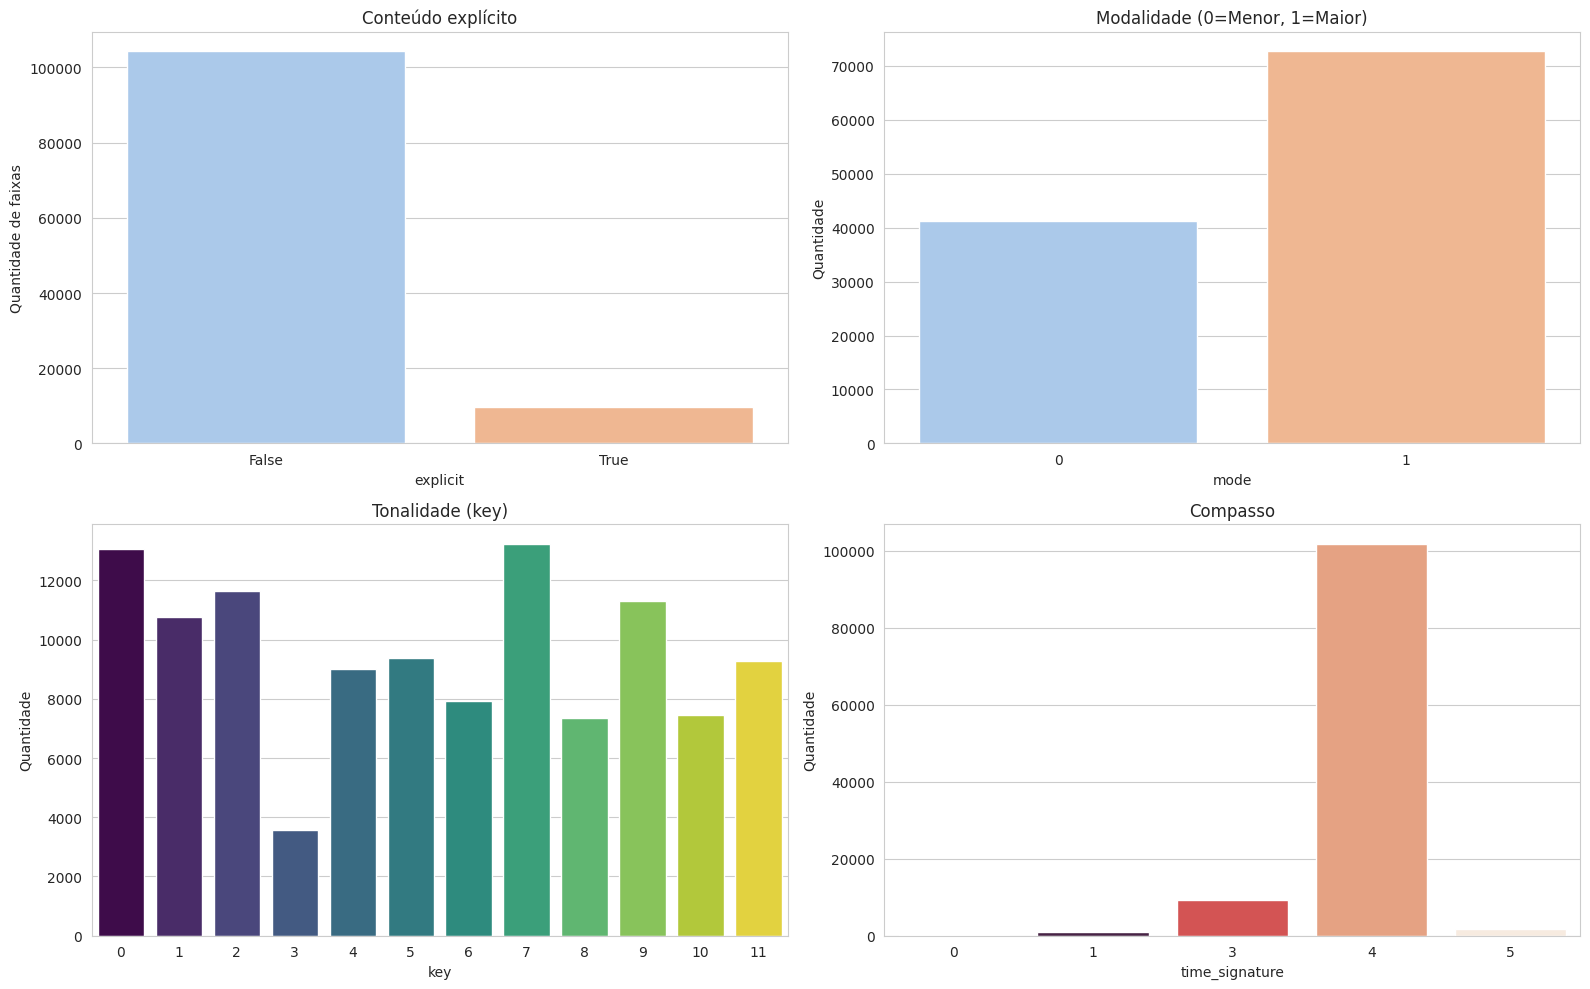

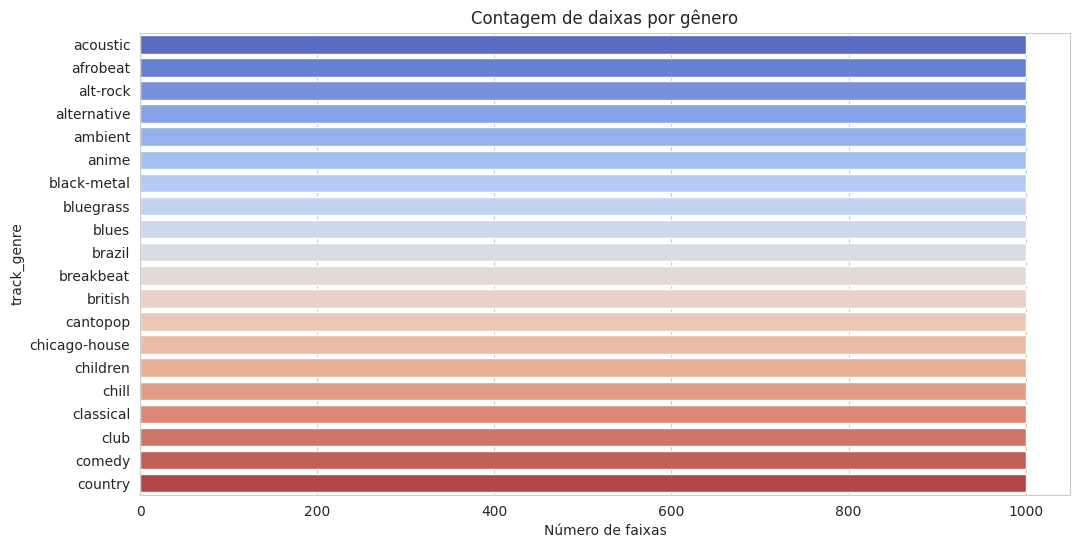

Contagem mínima por gênero: 1000
Contagem máxima por gênero: 1000


In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

# explicito
sns.countplot(x=df['explicit'], ax=ax[0, 0], hue=df['explicit'], palette='pastel', legend=False)
ax[0, 0].set_title('Conteúdo explícito')
ax[0, 0].set_ylabel('Quantidade de faixas')

# modalidade
sns.countplot(x=df['mode'], ax=ax[0, 1], hue=df['mode'], palette='pastel', legend=False)
ax[0, 1].set_title('Modalidade (0=Menor, 1=Maior)')
ax[0, 1].set_ylabel('Quantidade')

# tonalidade
sns.countplot(x=df['key'], ax=ax[1, 0], hue=df['key'], palette='viridis', legend=False)
ax[1, 0].set_title('Tonalidade (key)')
ax[1, 0].set_ylabel('Quantidade')

# compasso
sns.countplot(x=df['time_signature'], ax=ax[1, 1], hue=df['time_signature'], palette='rocket', legend=False)
ax[1, 1].set_title('Compasso')
ax[1, 1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

# plotar os 20 primeiros (todos iguais) para confirmar se todos têm a mesma quantidade
plt.figure(figsize=(12, 6))
genre_counts = df['track_genre'].value_counts().head(20)
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette='coolwarm', legend=False)
plt.title('Contagem de daixas por gênero')
plt.xlabel('Número de faixas')
plt.show()

# confirmar estatisticamente
print(f"Contagem mínima por gênero: {df['track_genre'].value_counts().min()}")
print(f"Contagem máxima por gênero: {df['track_genre'].value_counts().max()}")

**metadados que definem a estrutura musical e a classificação das faixas para entender o perfil da base de dados.**

1. Explícito: A base é predominantemente não explícita. Faixas explícitas representam a minoria.
* Essa variável será numérica (1/0) na próxima etapa.

2. Modalidade Tonalidade:
* Predominância do modo maior contra o modo menor. Escalas maiores são associadas a sensações de alegria.
* As tonalidades apresentam uma distribuição equilibrada.

3. Compasso: Predominância quase absoluta do compasso 4/4.
* Estrutura rítmica padrão da música ocidental, diferenciações são mais raras

4. Distribuição de gêneros: A contagem é exata, 1.000 faixas para cada gênero.
* Este conjunto de dados foi selecionado artificialmente para ter balanceamento perfeito entre as classes.
* Nao podemos contar a quantidade de músicas por gênero como informação relevante

### Encontrar duplicatas

Total de linhas originais: 114000
Duplicatas encontradas: 32656
Porcentagem de redundância: 28.65%


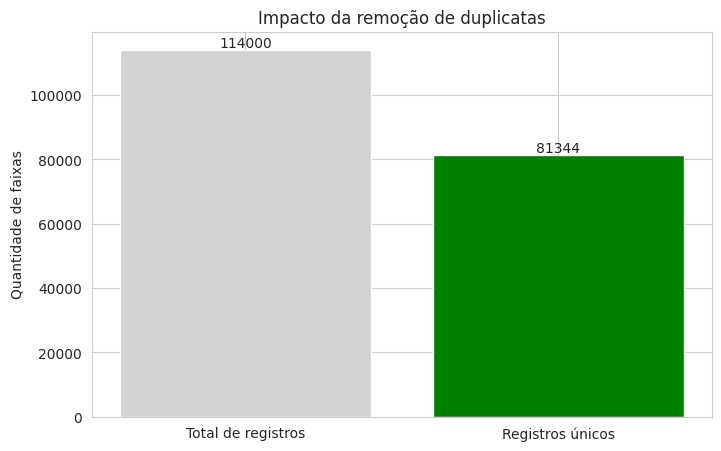


 Exemplo


,artists,track_name,album_name,popularity
93440,Nikolay Kopylov,"""Don Carlos"" Roderigo'S Death Aria",Popular Opera Arias,0
93397,Nikolay Kopylov,"""Don Carlos"" Roderigo'S Death Aria",Popular Opera Arias,0
39446,Felix Mendelssohn;Christopher Herrick;Simon Pr...,"""Hark! The Herald Angels Sing""",Klassische Weihnachtsmusik,0
16385,Felix Mendelssohn;Christopher Herrick;Simon Pr...,"""Hark! The Herald Angels Sing""",Klassische Weihnachtsmusik,0
111402,Kid Koala,"""Was He Slow?"" - Music From The Motion Picture...",Baby Driver (Music from the Motion Picture),25
111315,Kid Koala,"""Was He Slow?"" - Music From The Motion Picture...","""Was He Slow?"" (Music From The Motion Picture ...",37
32514,Aphex Twin,#3,Selected Ambient Works Volume II,64
4152,Aphex Twin,#3,Selected Ambient Works Volume II,64


In [ ]:
# contando duplicatas baseadas em Nome + Artista
duplicatas = df.duplicated(subset=['track_name', 'artists'], keep='first').sum()
total_linhas = len(df)

print(f"Total de linhas originais: {total_linhas}")
print(f"Duplicatas encontradas: {duplicatas}")
print(f"Porcentagem de redundância: {(duplicatas/total_linhas)*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.bar(['Total de registros', 'Registros únicos'], [total_linhas, total_linhas - duplicatas], color=['lightgray', 'green'])
plt.title('Impacto da remoção de duplicatas')
plt.ylabel('Quantidade de faixas')

plt.text(0, total_linhas, f'{total_linhas}', ha='center', va='bottom')
plt.text(1, total_linhas - duplicatas, f'{total_linhas - duplicatas}', ha='center', va='bottom')
plt.show()

# exemplo de duplicata
exemplo_duplicada = df[df.duplicated(subset=['track_name', 'artists'], keep=False)].sort_values(by='track_name').head(8)
print("\n Exemplo")
display(exemplo_duplicada[['artists', 'track_name', 'album_name', 'popularity']])

**Utilizando a combinação de Nome da Música + Artista como chave única**

* Total de registros originais: 114.000
* Registros únicos: 81.344
* Duplicatas encontradas: 32.656
* Taxa de redundância: 28.65%

-> Quase um terço do banco de dados é composto por repetições, causadas pelo fato de a mesma música ser lançada em álbuns diferentes. A mesma música possui popularidades diferentes, confundindo as estatísticas

* A remoção dessas 32 mil duplicatas é obrigatória. Manteremos apenas a ocorrência mais popular de cada faixa para garantir que a musica tenha peso único.

### 3.4 Conclusão e proximo passo

**Regras de limpeza:**

1.  **Muitos zeros:** Remover faixas com `popularity == 0`, pois representam dados desconhecidos ou não validados pelo público.
2.  **Foco em Canções:**
    * **Duração:** Manter apenas faixas entre **30s e 10min**, sem podcasts, sets longos e erros de gravação.
    * **Fala:** Remover faixas com `speechiness > 0.66`, sem interlúdios e conteúdo falado que não é música.
    * **Volume:** Remover faixas com `loudness < -40dB`, sem silêncio/erro técnico.
3.  **Duplicatas:** Remover entradas repetidas baseadas na combinação `Nome da música` + `Artista`.
4.  **Engenharia de atributos:**
    * **Legibilidade** Converter `duration_ms` (milissegundos) para `duration_min` (minutos).
5.  **Metadados:**
    * Converter a coluna `explicit` de `booleano` para `numérico`.
    * Remover colunas de id irrelevantes (`track_id`, `Unnamed: 0`).

# 4. Pré-processamento e engenharia de atributos
* Limpar e refinar o dataset para garantir que nossa análise responda às perguntas sem ruídos e redundâncias.

## 4.1. Limpeza de Escopo e Ruído
* Aplicação dos filtros definidos anteriormente, com o objetivo de remover dados que não se comportam como músicas populares ou com erros.

*   Remoção de Zeros
*   Remoção de faixas com speechiness > 0.66
*   Limitação da duração entre 30s e 10min, volume acima de -40dB.

In [ ]:
print("Filtros de limpeza")
df_final = df.copy()
qtd_inicial = len(df_final)

# regras definidas na AED
# zeros
df_final = df_final[df_final['popularity'] > 0]

# duração
df_final = df_final[(df_final['duration_ms'] >= 30000) & (df_final['duration_ms'] <= 600000)]

# loudness
df_final = df_final[df_final['loudness'] >= -40]

# speechiness
df_final = df_final[df_final['speechiness'] <= 0.66]

print(f"Linhas antes dos filtros: {qtd_inicial}")
print(f"Linhas após filtros: {len(df_final)}")

Filtros de limpeza
Linhas antes dos filtros: 114000
Linhas após filtros: 96572


## 4.2. Duplicatas
* Estratégia específica para lidar com a redundância de quase 30% dos dados. A mesma música (mesmo nome e artista) aparecia múltiplas vezes, inclusive com popularidades diferentes.

* Ordenamos o dataset por popularidade decrescente e removemos mantendo a primeira ocorrência, garantindo que a versão da música que permaneceu na base é a de maior sucesso.

In [ ]:
print("\nDuplicatas")

# mais populares ficam no topo
df_final = df_final.sort_values(by='popularity', ascending=False)

# mantendo a primeira
df_final = df_final.drop_duplicates(subset=['track_name', 'artists'], keep='first')

# resetando o index
df_final = df_final.reset_index(drop=True)

print(f"Linhas após remoção de duplicatas: {len(df_final)}")


Duplicatas
Linhas após remoção de duplicatas: 75241


## 4.3. Engenharia de atributos e metadados
-> ajustamos as variáveis para facilitar a leitura humana e a correlação matemática.

* Legibilidade (ms para min)
* Explicit convertida de booleano para binário (1/0).
* Remoção das colunas de ID (track_id, Unnamed: 0) e a antiga duration_ms

In [ ]:
print("\nAjuste de colunas")

# ms para minutos
df_final['duration_min'] = round(df_final['duration_ms'] / 60000, 2)

# explicit True/False -> 1/0
df_final['explicit'] = df_final['explicit'].astype(int)

# drop colunas desnecessárias
cols_drop = ['Unnamed: 0', 'track_id', 'duration_ms']
df_final = df_final.drop(columns=cols_drop, errors='ignore')

# resultado final
print("\nConcluído\n")
print(f"Total de registros removidos: {qtd_inicial - len(df_final)}")
print(f"Tamanho final da base: {len(df_final)}")
df_final.head()


Ajuste de Colunas

Concluído

Total de registros removidos: 38759
Tamanho final da base: 75241


,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,0,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,pop,2.62
1,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,0,0.621,0.782,2,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop,3.32
2,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,1,0.561,0.965,7,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,pop,2.92
3,Manuel Turizo,La Bachata,La Bachata,98,0,0.835,0.679,7,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latino,2.71
4,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,1,0.911,0.712,1,-5.105,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,latino,2.98


# 5. Perguntas de Negócio: O que define o sucesso?

* O objetivo desta seção é identificar quais variáveis influenciam estatisticamente a chance de uma música ser popular. Antes de iniciar as perguntas, vamos criar a categorização de popularidade no nosso dataset limpo para facilitar as comparações entre grupos.

In [ ]:
# sem zeros, a faixa agora é de 1 a 100
bins = [0, 50, 75, 100]
labels = ['Baixa (1-50)', 'Média (51-75)', 'Alta (76-100)']

df_final['faixa_popularidade'] = pd.cut(
    x=df_final['popularity'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("Distribuição de músicas por faixa de popularidade:")
print(df_final['faixa_popularidade'].value_counts())

Distribuição de músicas por faixa de popularidade:
faixa_popularidade
Baixa (1-50)     56180
Média (51-75)    17819
Alta (76-100)     1242
Name: count, dtype: int64


## 5.1 Quais atributos musicais apresentam maior correlação com a popularidade das músicas?

-> Coeficiente de Correlação entre a popularity e todos os outros atributos numéricos.

Para analise:
* Valor próximo de 1: Quanto maior o atributo, maior a popularidade.

*   Item da lista
*   Item da lista


* Valor próximo de -1: Quanto maior o atributo, menor a popularidade.

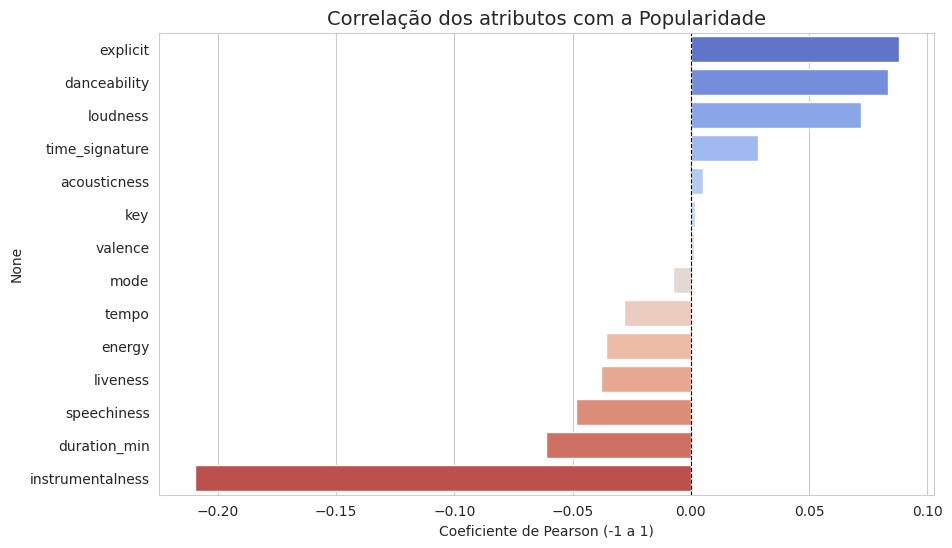

Top 3 correlações positivas
explicit        0.087979
danceability    0.083266
loudness        0.071976
Name: popularity, dtype: float64

Top 3 correlações negativas ---
speechiness        -0.048678
duration_min       -0.061409
instrumentalness   -0.209801
Name: popularity, dtype: float64


In [ ]:
# calculando a correlação de todas as numéricas com 'popularity', menos com ela mesmo
correlacoes = df_final.corr(numeric_only=True)['popularity'].sort_values(ascending=False)
correlacoes = correlacoes.drop('popularity')

# visualização
plt.figure(figsize=(10, 6))
sns.barplot(x=correlacoes.values, y=correlacoes.index, hue=correlacoes.index, palette='coolwarm', legend=False)
plt.title('Correlação dos atributos com a Popularidade', fontsize=14)
plt.xlabel('Coeficiente de Pearson (-1 a 1)')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.show()

print("Top 3 correlações positivas")
print(correlacoes.head(3))
print("\nTop 3 correlações negativas ---")
print(correlacoes.tail(3))

1. Impulsiona a popularidade (Correlações positivas):

* Explicit (+0.088): O atributo com maior correlação positiva é o conteúdo explícito, sugerindo que gêneros dominantes no mainstream atual utilizam letras explícitas

* Danceability (+0.083): A capacidade de uma música ser dançante é o segundo maior motivo de popularidade. O público gosta de faixas animadas.

* Loudness (+0.072): Músicas com volume mais alto tendem a se destacar e performar melhor, indicando que o público gosta de sons com volumes elevados.

2. Prejudica a popularidade (Correlações negativas):

* Instrumentalness (-0.210): Indica uma forte preferência do mercado por faixas com vocais, as músicas puramente instrumentais enfrentam grandes dificuldades para atingir alta popularidade no Spotify.

* Duration_min (-0.061): Sugere uma tendência por músicas mais curtas e diretas, as faixas muito longas tendem a ter pior desempenho. Esse comportamento vem sendo notado em todos os tipos de plataformas e conteúdos, e afeta também a indústria musical

-> Não existe uma fórmula mágica, mas o perfil  de uma música popular é:
* ela tende a ser vocal, curta, alta, dançante e explícita.

## 5.2 Dançabilidade: Influencia a popularidade? Definida por ritmo ou velocidade?

*   Item da lista
*   Item da lista



-> Já sabemos que dançabilidade é um fator chave para a popularidade. Então o que torna uma música dançante para o algoritmo do Spotify?
* Pensando nisso, comparamos a média de Danceability e Tempo (BPM) entre as faixas de baixa e alta popularidade.

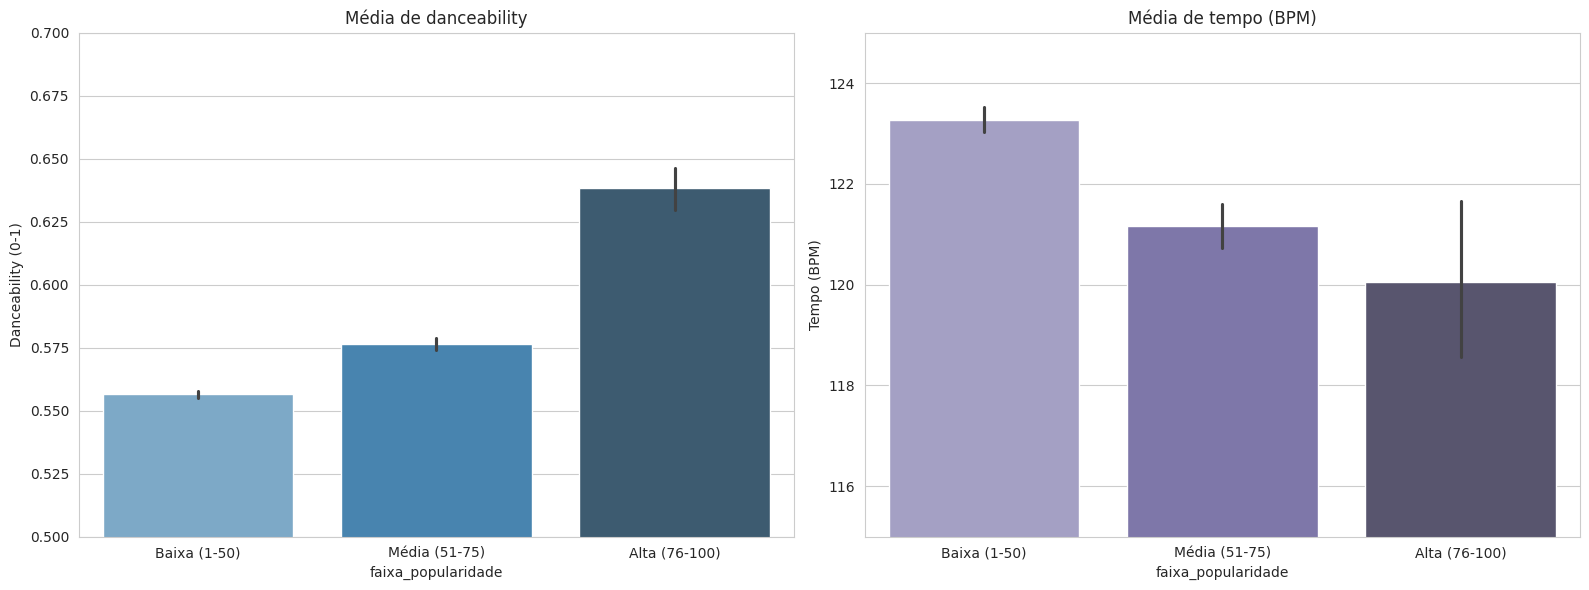

Correlação entre Danceability e BPM: -0.030


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# confirmaçao da popularidade x dançabilidade
sns.barplot(
    x='faixa_popularidade', y='danceability',
    data=df_final, hue='faixa_popularidade', palette='Blues_d', ax=ax[0], legend=False
)
ax[0].set_title('Média de danceability')
ax[0].set_ylim(0.5, 0.7)
ax[0].set_ylabel('Danceability (0-1)')

# bpm x dançabilidade
sns.barplot(
    x='faixa_popularidade', y='tempo',
    data=df_final, hue='faixa_popularidade', palette='Purples_d', ax=ax[1], legend=False
)
ax[1].set_title('Média de tempo (BPM)')
ax[1].set_ylim(115, 125)
ax[1].set_ylabel('Tempo (BPM)')

plt.tight_layout()
plt.show()

# Correlação entre ser dançante e ser rápido
corr_dance_tempo = df_final['danceability'].corr(df_final['tempo'])
print(f"Correlação entre Danceability e BPM: {corr_dance_tempo:.3f}")

* 1. O primeiro gráfico confirma a hipótese de que faixas de classe Alta (76-100) são mais dançantes (média 0.63) do que as da classe Baixa (média 0.56).

* 2. O segundo gráfico revela que as músicas mais populares não são as mais rápidas em BPM. Inclusive, por mais que pouco, músicas de maior sucesso tendem a ir para o tempo mais controlado.

* 3. Correlação Danceability x Tempo: resultou em -0.030, provando que não existe relação linear entre velocidade e dançabilidade.

### O que define a Dançabilidade?
* O algoritmo avalia a estabilidade do ritmo, a força da batida e a regularidade geral, se é previsível... Não tem a ver com os BPMs.

> Exemplo: Um Funk ou Reggaeton com 90 BPM tende a ter alta dançabilidade pois possui uma batida forte, marcada e constante. Já um Solo de Metal a 180 BPM pode ter baixa dançabilidade devido à dificuldade do passo de dança.

* O mercado favorece o ritmo estável em vez da velocidade. Músicas populares tendem a ter batidas claras e previsíveis.

### **5.3. A energia das músicas influencia a popularidade da mesma forma que a danceability?**

-> A variável **Energy** mede a intensidade e a atividade da faixa (músicas rápidas, altas). Investigamos se o público do Spotify favorece músicas mais intensas ou mais calmas.


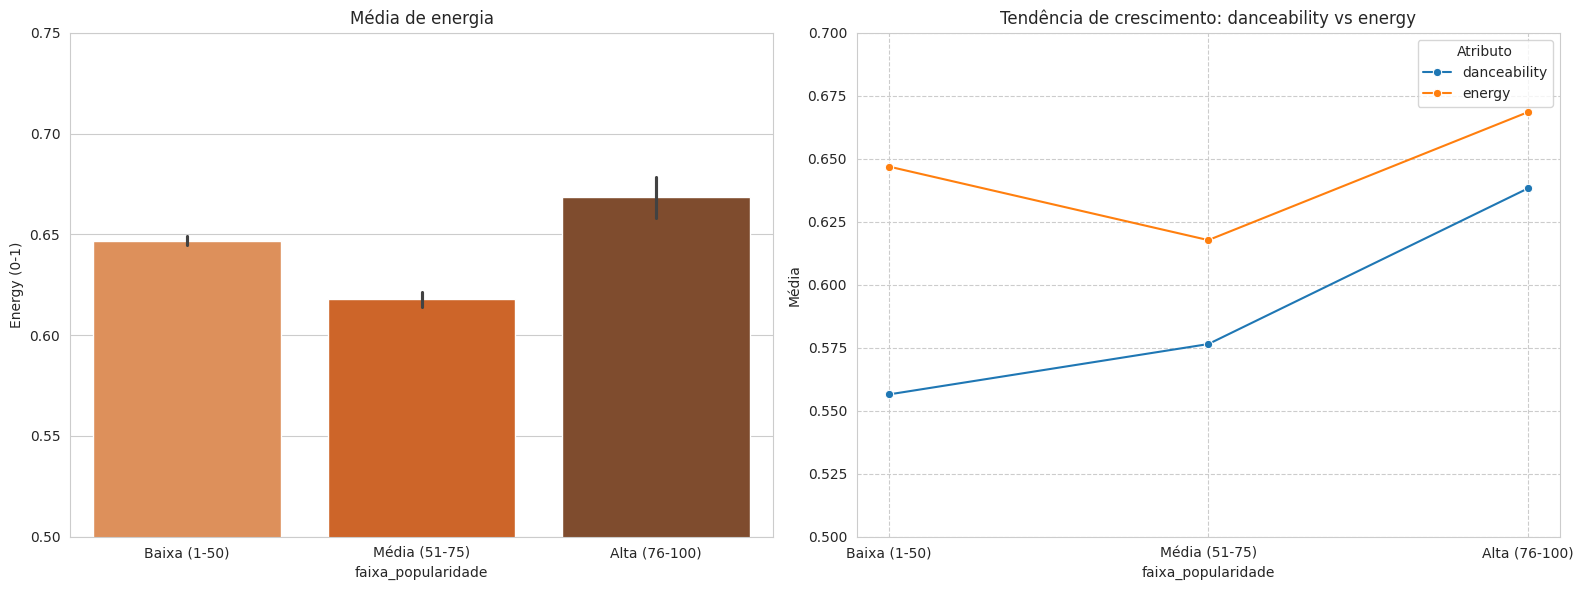

Média de energia (baixa popularidade): 0.647
Média de energia (alta popularidade):  0.669
Crescimento percentual: 3.34%


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# média de energia por faixa
sns.barplot(
    x='faixa_popularidade', y='energy',
    data=df_final, hue='faixa_popularidade', palette='Oranges_d', ax=ax[0], legend=False
)
ax[0].set_title('Média de energia')
ax[0].set_ylim(0.5, 0.75)
ax[0].set_ylabel('Energy (0-1)')

# danceability vs energy, média das duas lado a lado
df_comparativo = df_final.groupby('faixa_popularidade', observed=False)[['danceability', 'energy']].mean().reset_index()
df_melted = df_comparativo.melt(id_vars='faixa_popularidade', var_name='Atributo', value_name='Média')

sns.lineplot(data=df_melted, x='faixa_popularidade', y='Média', hue='Atributo', marker='o', ax=ax[1])
ax[1].set_title('Tendência de crescimento: danceability vs energy')
ax[1].set_ylim(0.5, 0.7)
ax[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

media_energy_baixa = df_final[df_final['faixa_popularidade'] == 'Baixa (1-50)']['energy'].mean()
media_energy_alta = df_final[df_final['faixa_popularidade'] == 'Alta (76-100)']['energy'].mean()

print(f"Média de energia (baixa popularidade): {media_energy_baixa:.3f}")
print(f"Média de energia (alta popularidade):  {media_energy_alta:.3f}")
print(f"Crescimento percentual: {((media_energy_alta - media_energy_baixa) / media_energy_baixa * 100):.2f}%")

1. Saturação de mercado: A energia já começa em um patamar elevado. Mesmo as músicas consideradas impopulares possuem uma média de energia de 0.647.
* Ter energia alta é o padrão, e não um diferencial dos sucessos.

2. A linha de energia está mais alta porque, em média, as músicas são mais energéticas do que dançantes, porém esse atributo não influencia mais na popularidade
* A energia não influencia a popularidade da mesma forma que a dançabilidade, e esta presente em músicas de sucesso e desconhecidas.

### **5.4. Existe um perfil de sucesso que caracteriza as músicas de maior popularidade?**

-> Diferente da Pergunta 1, que mostrou a direção das tendências, esta pergunta quer definir o **perfil exato** de uma música de sucesso.
* Utilizando um mapa de calor das médias, traçamos esse perfil que atinge a classificação Alta (76-100).

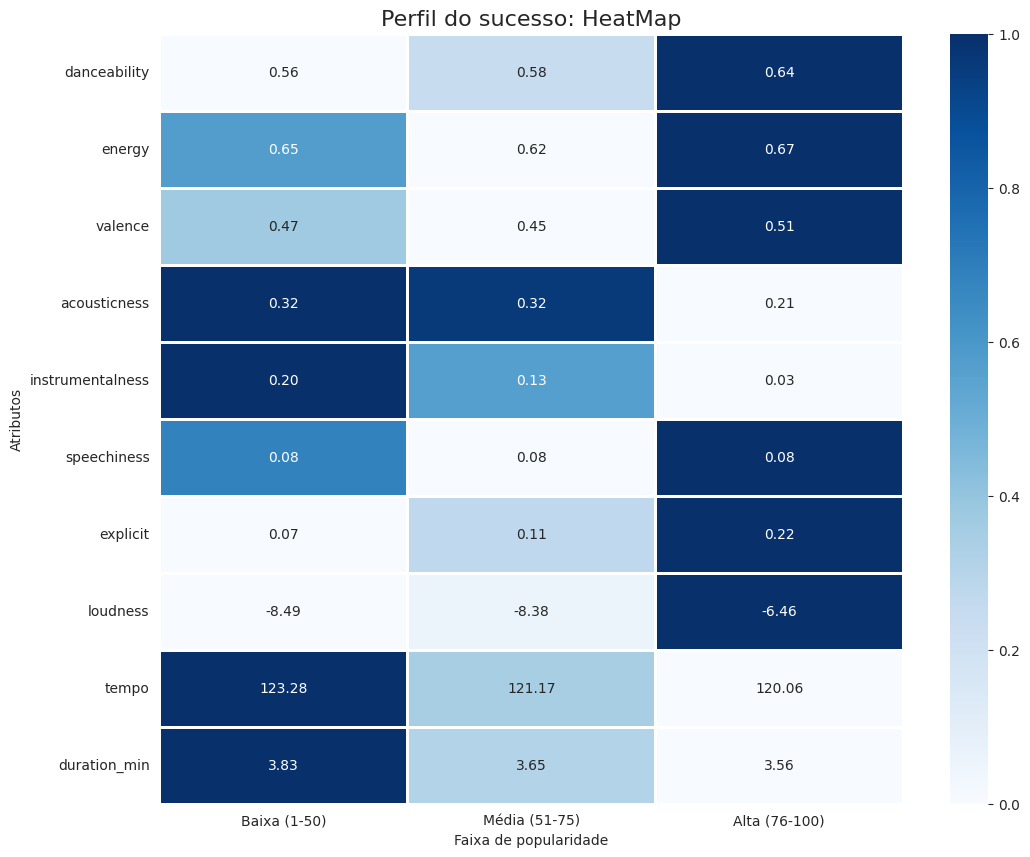

Perfil médio da música Popular
danceability          0.638222
energy                0.668504
valence               0.512193
acousticness          0.211314
instrumentalness      0.027809
speechiness           0.084520
explicit              0.224638
loudness             -6.459330
tempo               120.058689
duration_min          3.563100
Name: Alta (76-100), dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# atributos do perfil
atributos_perfil = [
    'danceability', 'energy', 'valence', 'acousticness',
    'instrumentalness', 'speechiness', 'explicit',
    'loudness', 'tempo', 'duration_min'
]

# média por faixa de popularidade
df_dna_real = df_final.groupby('faixa_popularidade', observed=False)[atributos_perfil].mean().reset_index()
df_dna_real = df_dna_real.set_index('faixa_popularidade').T

# média normalizada para as cores
df_dna_cores = df_dna_real.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

# exibição
plt.figure(figsize=(12, 10))
sns.heatmap(df_dna_cores, annot=df_dna_real, cmap="Blues", fmt=".2f", linewidths=1)
plt.title("Perfil do sucesso: HeatMap", fontsize=16)
plt.xlabel("Faixa de popularidade")
plt.ylabel("Atributos")
plt.show()

print("Perfil médio da música Popular")
print(df_dna_real['Alta (76-100)'])

* Duração: O hit médio dura 3.56 minutos, otimizadas para o rádio e repetição em playlists.

* Volume: A média é -6.46 dB, mais alto do que as faixas impopulares (-8.49 dB), confirmando que músicas comerciais são mais barulhentas.

* Tempo (BPM): O hit médio tem 120 BPM, mais lento do que as faixas impopulares (123 BPM), pois a estabilidade rítmica tem mais valor do que a velocidade.

* Liberdade explícita: Maior diferenciador do gráfico, com um salto de 7% (Baixa) para 22% (Alta). O uso de linguagem explícita é 3x mais comum nas músicas populares, se mostrando muito relevante.

* Vocal: A instrumentalidade cai muito nas faixas de sucesso, mostrando que a presença da voz é praticamente obrigatória.

* Acústico: A acusticidade cai de 0.32 para 0.21. O sucesso tende a ser produzido com menos elementos acústicos.

## Perfil final
* Uma produção vocal eletrificada e alta (-6dB), com duração de repetição em playlists (3min30s), batida dançante estável (120 BPM) e alta liberdade para uso de linguagem explícita.

# 6. Conclusão Final

## 6.1. Faxina nos dados
Este projeto provou que a qualidade da análise depende 100% da limpeza feita antes. Ao investigar o dataset do Spotify, descobrimos que **grande parte dos dados eram duplicatas e ruídos** (popularidade zero, silêncio ou podcasts).
A decisão de aplicar um pré-processamento foi o que garantiu que nossas conclusões fossem reais e não distorcidas por sujeira.

## 6.2. Perfil do sucesso
Respondendo à pergunta principal: **existe uma receita para o sucesso?** Sim. Os dados mostraram que o hit moderno no Spotify tem características bem definidas:
* **Formato rápido:** Duração média de **3min 30s**.
* **Produção intensa:** Volume alto (**-6.5 dB**) e pouca acusticidade, batidas previsíveis e fortes.
* **Voz obrigatória:** vocal é essencial.
* **Liberdade total:** O uso de linguagem explícita é **3x mais frequente** nas músicas do topo do que nas impopulares.
* **Velocidade não é dançabilidade:** Os hits são **mais lentos** e estáveis
* **Energia é padrão** Quase toda música hoje em dia é enérgica

## 6.3. Próximos passos
Com a análise exploratória concluída, pudemos perceber que, com as fortes correlações que encontramos, modelos de classificação teriam sucesso em prever a popularidade de novas faixas baseados em seus atributos.